In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# TODO: dataset loading with basic optimization
file_path = "data/raw_esg_financial_data.csv"
df = pd.read_csv(file_path)

try:
    df = pd.read_csv(
        file_path,
        low_memory=False  # avoids dtype warnings
    )
    print("Dataset loaded successfully")
except Exception as e:
    print("Error loading dataset:", e)

Dataset loaded successfully


In [9]:
#TODO: Preview first few rows, structure of dataset

df.head(20)


,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
1,1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4
2,1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9
3,1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2
4,1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8
5,1,Company_1,Retail,Latin America,2020,567.5,6.0,384.1,2.3,55.7,65.1,28.5,73.5,42245.4,21122.7,84490.9
6,1,Company_1,Retail,Latin America,2021,604.2,5.2,479.3,6.5,55.6,66.8,25.5,74.6,44263.8,22131.9,88527.7
7,1,Company_1,Retail,Latin America,2022,593.2,4.2,248.4,-1.8,57.7,69.0,27.1,76.9,42536.3,21268.2,85072.6
8,1,Company_1,Retail,Latin America,2023,636.7,5.3,373.9,7.3,57.8,68.3,27.0,78.1,45956.3,22978.2,91912.6
9,1,Company_1,Retail,Latin America,2024,687.0,4.6,460.1,7.9,58.5,68.9,29.9,76.8,49289.1,24644.5,98578.1


In [10]:
print("Shape of dataset:", df.shape)
print("\nColumn names:\n", df.columns.tolist())

Shape of dataset: (11000, 16)

Column names:
 ['CompanyID', 'CompanyName', 'Industry', 'Region', 'Year', 'Revenue', 'ProfitMargin', 'MarketCap', 'GrowthRate', 'ESG_Overall', 'ESG_Environmental', 'ESG_Social', 'ESG_Governance', 'CarbonEmissions', 'WaterUsage', 'EnergyConsumption']


In [13]:
#TODO: Checking dtypes, memory usage, statistical summary of numerical columns
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CompanyID          11000 non-null  int64  
 1   CompanyName        11000 non-null  str    
 2   Industry           11000 non-null  str    
 3   Region             11000 non-null  str    
 4   Year               11000 non-null  int64  
 5   Revenue            11000 non-null  float64
 6   ProfitMargin       11000 non-null  float64
 7   MarketCap          11000 non-null  float64
 8   GrowthRate         10000 non-null  float64
 9   ESG_Overall        11000 non-null  float64
 10  ESG_Environmental  11000 non-null  float64
 11  ESG_Social         11000 non-null  float64
 12  ESG_Governance     11000 non-null  float64
 13  CarbonEmissions    11000 non-null  float64
 14  WaterUsage         11000 non-null  float64
 15  EnergyConsumption  11000 non-null  float64
dtypes: float64(11), int64(2), str(3)


,CompanyID,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
count,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,10000.000000,11000.000000,11000.000000,11000.000000,11000.000000,1.100000e+04,1.100000e+04,1.100000e+04
mean,500.500000,2020.000000,4670.850591,10.900455,13380.622236,4.830370,54.615273,56.416991,55.660582,51.767655,1.271462e+06,5.600442e+05,1.165839e+07
std,288.688113,3.162421,9969.954369,8.758711,39922.870373,9.424787,15.893937,26.767233,23.356152,25.323370,5.067760e+06,1.565686e+06,5.095836e+07
min,1.000000,2015.000000,35.900000,-20.000000,1.800000,-36.000000,6.300000,0.000000,0.000000,0.000000,2.042200e+03,1.021100e+03,5.105500e+03
25%,250.750000,2017.000000,938.775000,5.300000,1098.525000,-1.325000,44.100000,34.700000,37.600000,30.775000,1.228530e+05,6.488467e+04,3.069161e+05
50%,500.500000,2020.000000,1902.300000,10.500000,3096.450000,4.900000,54.600000,55.600000,55.150000,52.100000,2.920734e+05,2.038805e+05,1.221745e+06
75%,750.250000,2023.000000,4342.625000,16.300000,9995.500000,11.000000,65.600000,79.000000,73.800000,73.000000,7.407311e+05,5.251880e+05,5.616437e+06
max,1000.000000,2025.000000,180810.400000,50.000000,865271.700000,38.000000,98.800000,100.000000,100.000000,100.000000,1.741047e+08,5.223142e+07,1.741047e+09


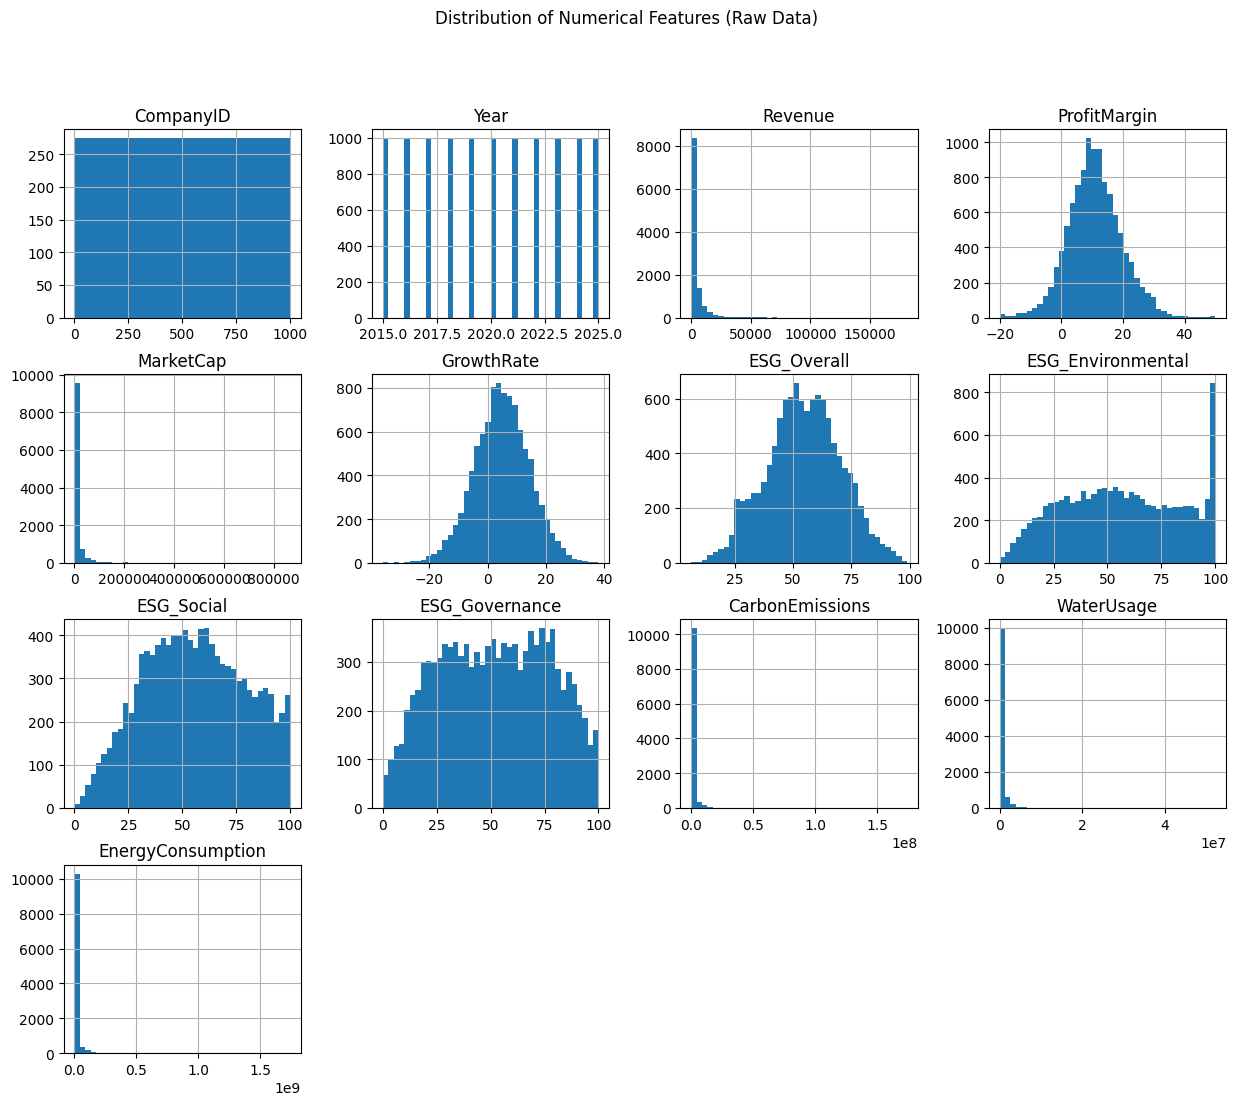

In [ ]:
#TODO: Plot distribution of all numerical columns

num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(figsize=(15,12), bins=40)
plt.suptitle("Distribution of Numerical Features (Raw Data)")
plt.show()